In [1]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

In [2]:
DIR = Path("../../artifacts/2023-08-s11/experiments/accuracy_basis/comparing-prca-variants")

In [3]:
def load(dataset, logit_mod, arch, layer, basis_name, basis_mode, seeds=list(range(1, 5+1))):
    
    arr_dfs = []
    for seed in seeds:
        with open(DIR / f"{dataset}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"]
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_acc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df

load(
    "cifar100-people--ts1.0", 
    "oneclass", 
    "cifar100-resnet18-p1",
    "layer4", 
    "prca", 
    basis_mode="centered",
    seeds=range(1, 5+1)
)

acc            seed original_acc  dims
       mean       std count        first first
k                                             
1    0.3660  0.000000     5         0.55   512
2    0.5004  0.000894     5         0.55   512
3    0.5440  0.000000     5         0.55   512
4    0.5520  0.000000     5         0.55   512
5    0.5560  0.000000     5         0.55   512
6    0.5580  0.000000     5         0.55   512
7    0.5580  0.000000     5         0.55   512
8    0.5580  0.000000     5         0.55   512
9    0.5560  0.000000     5         0.55   512
10   0.5580  0.000000     5         0.55   512
11   0.5600  0.000000     5         0.55   512
12   0.5560  0.000000     5         0.55   512
13   0.5540  0.000000     5         0.55   512
14   0.5540  0.000000     5         0.55   512
15   0.5540  0.000000     5         0.55   512
16   0.5540  0.000000     5         0.55   512
17   0.5540  0.000000     5         0.55   512
18   0.5540  0.000000     5         0.55   512
19   0.5556  0.000894     5         0.55   512
20   0.5540  0.000000     5         0.55   512
21   0.5540  0.000000     5         0.55   512
22   0.5540  0.000000     5         0.55   512
23   0.5540  0.000000     5         0.55   512
24   0.5560  0.000000     5         0.55   512
25   0.5540  0.000000     5         0.55   512
26   0.5540  0.000000     5         0.55   512
27   0.5540  0.000000     5         0.55   512
28   0.5540  0.000000     5         0.55   512
29   0.5540  0.000000     5         0.55   512
30   0.5524  0.000894     5         0.55   512
31   0.5540  0.000000     5         0.55   512
32   0.5540  0.000000     5         0.55   512
64   0.5540  0.000000     5         0.55   512
128  0.5540  0.000000     5         0.55   512
256  0.5540  0.000000     5         0.55   512
512  0.5500  0.000000     5         0.55   512

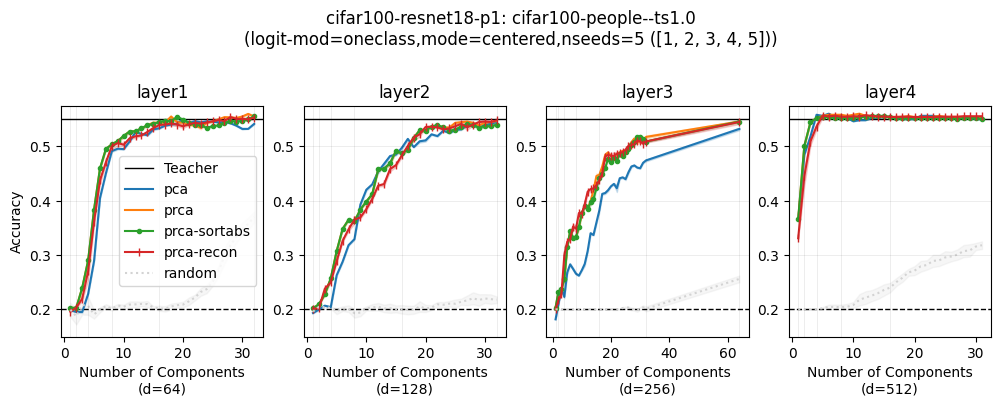

In [7]:
import numpy as np 

def color(name):
    if "random" in name:
        return "lightgray"
    elif name == "rel-abs"  or name == "act-abs":
        return plt.gca().lines[-1].get_color()
#     elif "pca" in name:
#         return "blue"
#     elif "prca" in name:
#         return "red"
    else:
        return None

def marker(name):
    if name in ["prca-abs", "prca-recon"]:
        return "|"
    elif name == "prca-v2":
        return "."
    elif "pcaprca" in name:
        return "."
    elif name in ["rel-abs", "act-abs"]:
        return "x"
    elif name == "random":
        return None
    else:
        return None

    
def alias(name):
    
    if name == "prca-v2":
        return "prca-sortabs"
    else:
        return name
    

def ls(name):
    if "rel" in name or "act" in name:
        return "--"
    elif "random" in name:
        return ":"
    else:
        return "-"
def viz(
    arch,
    dataset, 
    training_size=1.0, 
    logit_mod="oneclass",
    basis_mode="centered", 
    layers=["layer3", "layer4"],
    basis_names=[
        "pca",
        "prca",
        "prca-v2",
        "prca-recon",
        "random", 
        
    ],
    seeds=list(range(1, 5+1))
):
    
    dataset =  f"{dataset}--ts{training_size}"

    ncols = len(layers)
    plt.figure(figsize=(ncols * 3, 3))
    
    for lix, (layer, factor) in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        plt.ylabel("Accuracy")
        for bix, basis_name in enumerate(basis_names):
            df = load(dataset, logit_mod, arch, layer, basis_name, basis_mode, seeds=seeds)
            d = df["dims"]["first"].values[-1]
            k = df.index

            nseeds =df["seed"]["count"].values[-1]

            if bix == 0:
                teacher_metric = df["original_acc"]["first"].values[-1]
                plt.ylim([0.15, teacher_metric+0.025])
                plt.axhline(teacher_metric, ls='-', lw=1, color="k", label="Teacher")
                plt.axhline(0.2, ls="--", lw=1, color="k")
            
            vcolor = color(basis_name)
            
            if "pcaprca" in basis_name:
                vcolor = plt.gca().lines[-1].get_color()
            
            selected =  k < d // factor

            stderr = df["acc"]["std"][selected] / (nseeds ** 0.5)
            mean = df["acc"]["mean"][selected]
            
            
            
            plt.plot(
                k[selected],
                mean,
                label=f"{alias(basis_name)}",
                color=vcolor,
                ls=ls(basis_name),
                marker=marker(basis_name)
            )
            
            plt.fill_between(
                k[selected],
                mean - stderr,
                mean + stderr,
                alpha=0.2,
                color=plt.gca().lines[-1].get_color()
            )
        
        for p in np.power(2, np.arange(int(np.log2(d//factor)))):
            if p  > d // factor:   
                continue
            plt.axvline(
                int(p), 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
        for v in [0.3, 0.4, 0.5]:
            plt.axhline(
                v, 
                ls="-", 
                lw=0.5,
                alpha=0.1,
                color="k", 
            )
        
        plt.xlabel(f"Number of Components\n(d={d})")

        if lix == 0:
            plt.legend()
        else:
            plt.ylabel("")
            
    plt.suptitle(f"{arch}: {dataset}\n(logit-mod={logit_mod},mode={basis_mode},nseeds={nseeds} ({seeds}))", y=1.2)

viz(
    arch="cifar100-resnet18-p1",
    dataset="cifar100-people",
    training_size=1.0,
    layers=[
        ("layer1", 1),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 16)
    ],

)


# Comparison on `cifar100-resnet18-p1`

## `basis_mode={centered, uncentered}` and `training_size={0.1, 0.5, 1.0}`

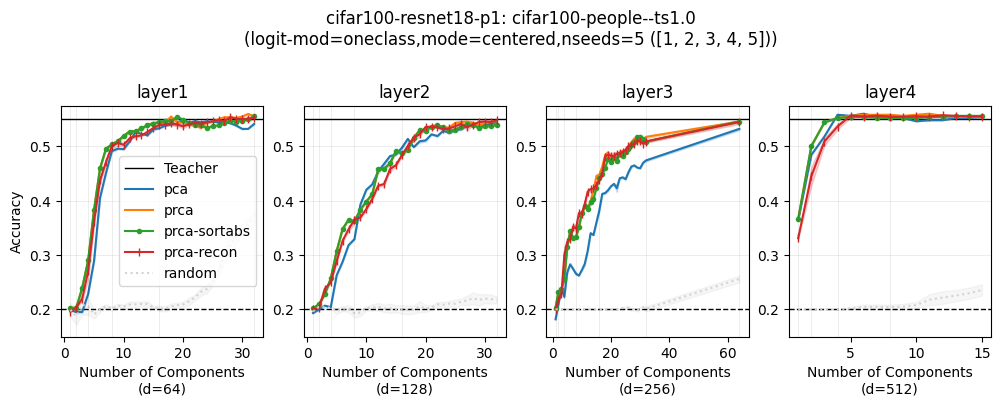

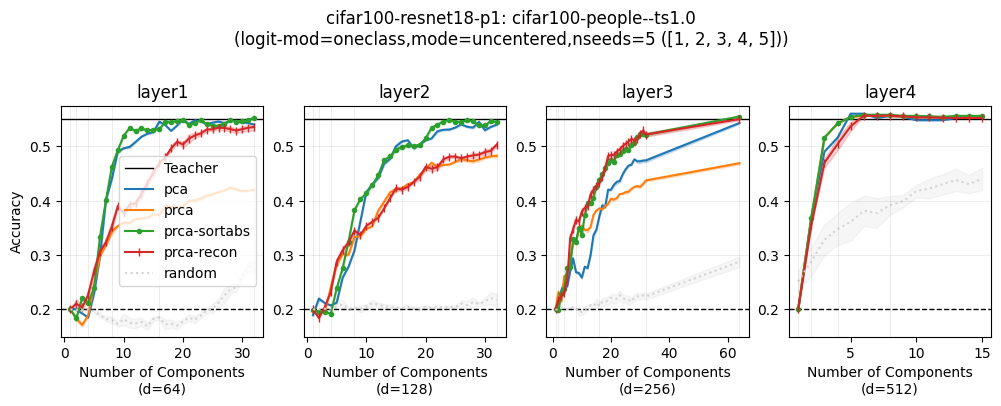

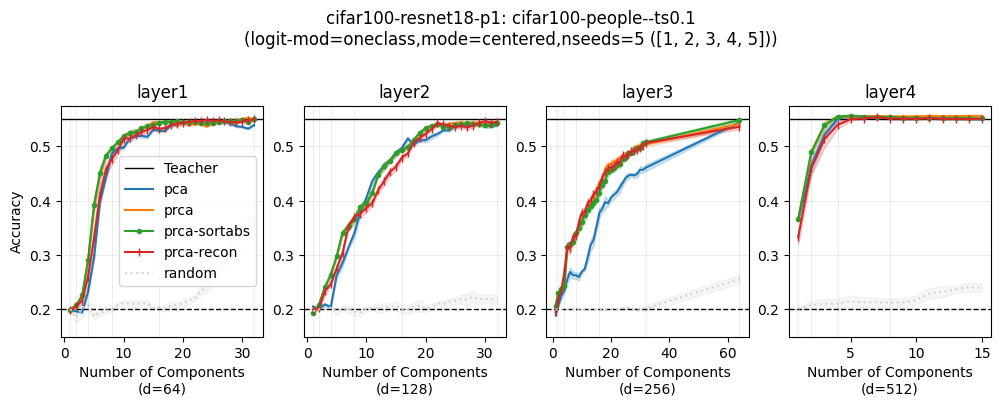

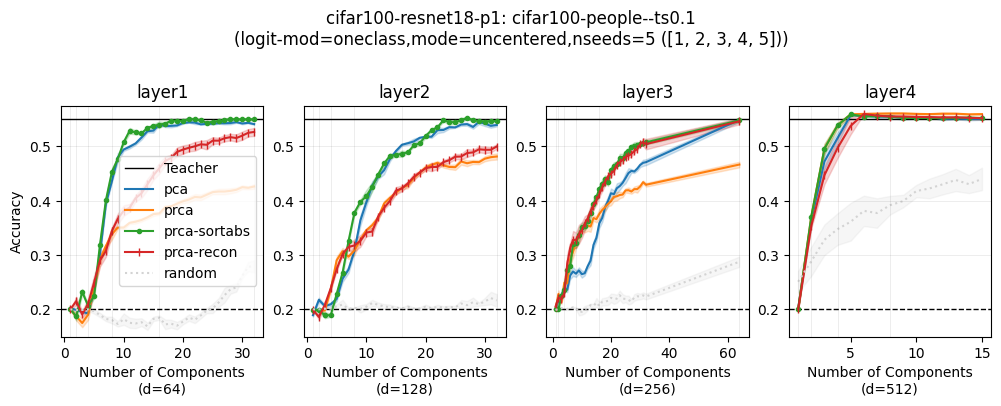

In [8]:
for training_size in [1.0, 0.1]:  
    for basis_mode in ["centered", "uncentered"]:
        viz(
            arch="cifar100-resnet18-p1",
            dataset="cifar100-people",
            training_size=training_size,
            basis_mode=basis_mode,
            layers=[
                ("layer1", 1),
                ("layer2", 2),
                ("layer3", 2),
                ("layer4", 32)
            ]
        )

# Comparison on `cifar100-resnet18-wb15`

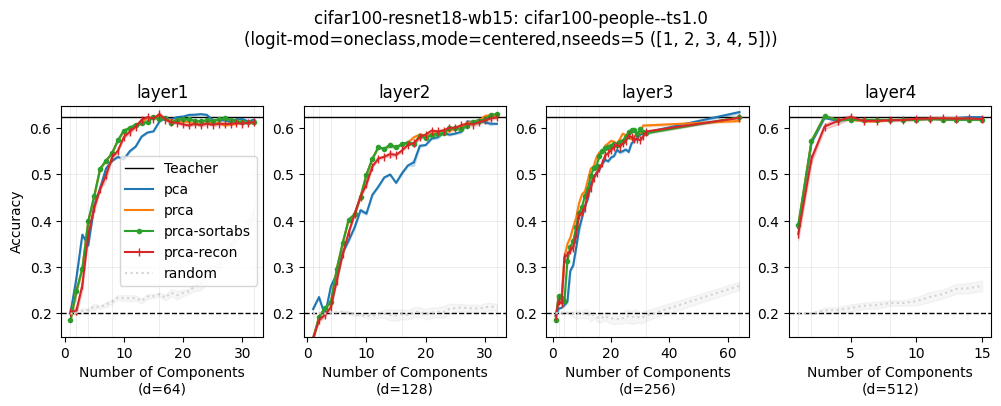

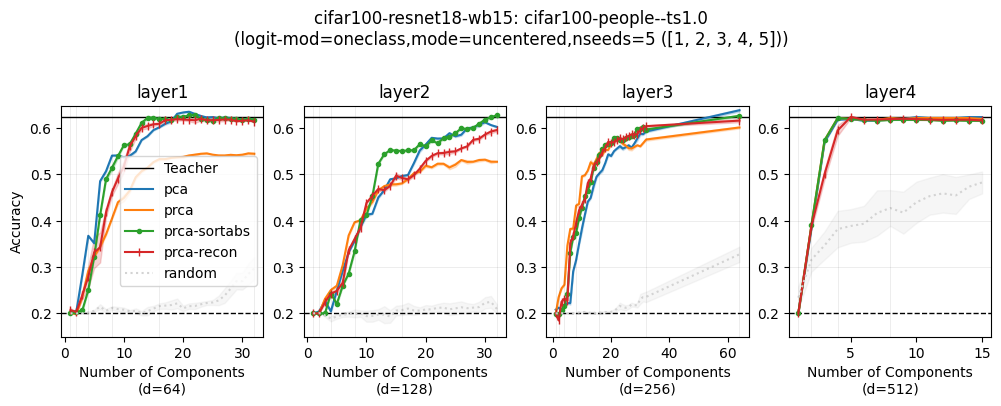

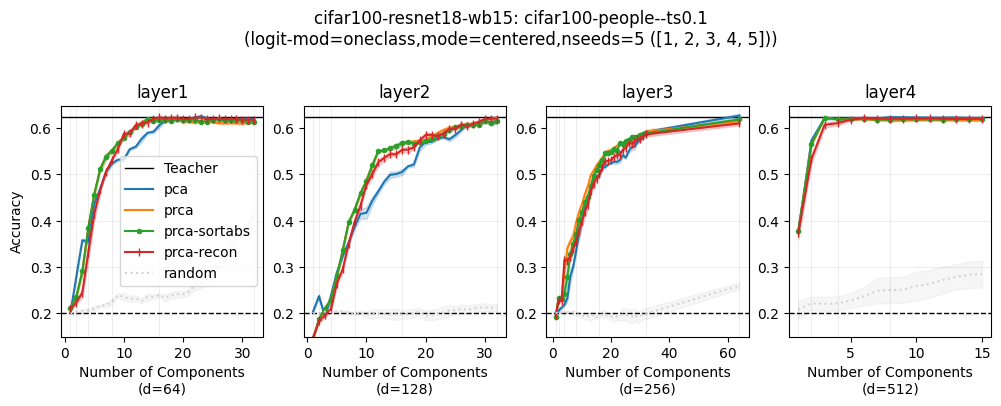

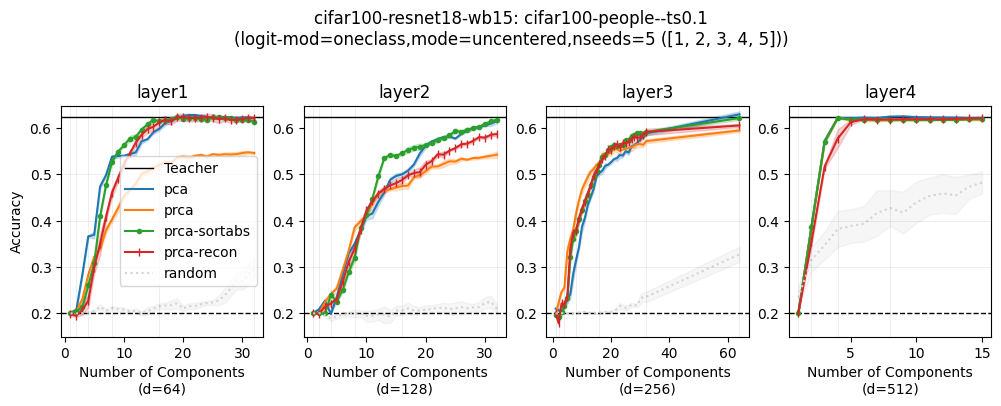

In [9]:
for training_size in [1.0, 0.1]:  
    for basis_mode in ["centered", "uncentered"]:
        viz(
            arch="cifar100-resnet18-wb15",
            dataset="cifar100-people",
            training_size=training_size,
            basis_mode=basis_mode,
            layers=[
                ("layer1", 1),
                ("layer2", 2),
                ("layer3", 2),
                ("layer4", 32)
            ]
        )

# Summary 

**Aim**: Here, we aim to compare different variants of PRCA. In particular, we particularly focus on the closed-form variant `prca` and `prca-v2` (sorted by absolute eigenvalues).

**Independent Variables**
- architecture: `{cifar100-resnet18-p1, cifar100-resnet18-wb15}`
- model: `{centered, uncentered}`
- training-size: `{1.0, 0.1}`

**Conclusion** From these configurations, the experiments show that PRCA-v2 is very competitive.
    

**Follow-up**
- replication on other CIFAR100 superclasses
- analysis on PRCA-v2 spectrum. 
- is there any theothetical justification?  